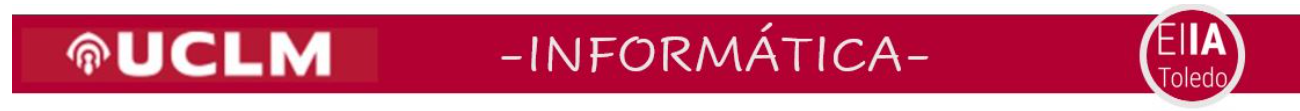

# Funciones recursivas
1. Definición
1. Ventajas y desventajas
1. Ejemplos de aplicación de recursividad
1. Medición de los tiempos de ejecución
1. Memorización o *Memoization*
1. Método "Divide y vencerás" y recursividad

## 1. Definición
Una función recursiva se llama a sí misma para resolver el mismo problema, pero más pequeño.


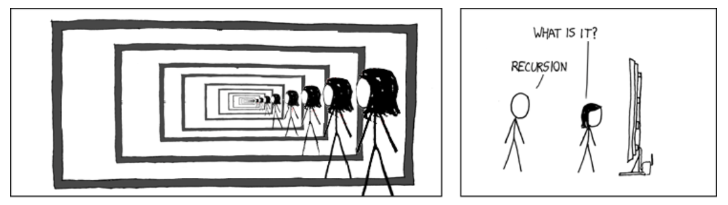


Fuente: xkcdsw.com


> *Students learning about recursion are sometimes* encouraged to **trace all the invocations** *of a recursive function on a piece of paper. … This exercise could be* **misleading**: *a programmer defining a recursive function usually* **does not think explicitly** *about the sequence of invocations that results from calling it. … How do you visualize all those invocations? You don’t have to.*
> <div style="text-align:right">Paul Graham</div>

### Expresión de una función recursiva
* Caso base
* Recurrencia o caso inductivo

In [ ]:
#Ejemplo de función recursiva:suma recursiva
def suma_recursiva(L):
  if len(L) == 1:
    return L[0]
  else:
    return L[0] + suma_recursiva(L[1:])

In [ ]:
print(suma_recursiva([1, 2, 3, 4, 5]))

15


In [ ]:
#No ejecutar
suma_recursiva([1, 2, 3, 4, 5])
  -> 1 + suma_recursiva([2, 3, 4, 5])
      -> 2 + suma_recursiva([3, 4, 5])
          -> 3 + suma_recursiva([4, 5])
              -> 4 + suma_recursiva([5])
                  -> 5
              -> 4 + 5 = 9
          -> 3 + 9 = 12
      -> 2 + 12 = 14
  -> 1 + 14 = 15

In [ ]:
#Ejemplo de función recursiva: cálculo del factorial de n
def fact_R(n):
    if n < 2: return 1
    return n * fact_R(n-1)
fact_R(3)

6

In [ ]:
#No ejecutar
fact_R(3)
  -> 3 * fact_R(2)
      -> 2 * fact_R(1)
          -> 1
      -> 2 * 1 = 2
  -> 3 * 2 = 6

Las funciones recursivas son una forma natural de expresar las **definiciones inductivas**, en las que se define algún **caso base y el valor n-ésimo en función de algún otro anterior**.

Son muy sencillas de entender, pero a veces pueden no ser nada eficientes.  

Una función recursiva no tiene nada de particular respecto al caso de una función que llama a otra función, pero evidentemente para que termine alguna vez tiene que tener dos partes:

* Uno o varios casos base, en los que el resultado se puede obtener directamente.
* Una recurrencia, o caso inductivo, o caso recursivo, en la que el resultado se determina en función de los resultados para casos más cercanos a los casos base.

En Python el **número de llamadas recursivas están limitadas**, según entorno de trabajo, deteniendo la ejecución con un error.

In [ ]:
import sys #módulo con funciones relativas al funcionamiento del intérprete de Python
print(sys.getrecursionlimit())
from platform import python_version
python_version()

1000


'3.10.12'

In [ ]:
#Ampliación del número de llamadas recursivas
sys.setrecursionlimit(5000)
print(sys.getrecursionlimit())

5000


## 2. Ventajas y desventajas

### Ventajas de la recursión
1. Las funciones recursivas facilitan hacer **código limpio y elegante**.
1. Es una expresión natural de la estrategia *divide y vencerás* (resuelve problemas mediante la resolución de casos más pequeños)
1. La **generación de secuencias es más fácil con recursión que con bucles anidados**.

### Desventajas de la recursión
1. A veces la lógica del programa puede hacerse **difícil de seguir**.
1. Las llamadas recursivas son **ineficientes**. Consumen tiempo y memoria.
1. Las funciones recursivas son **difíciles de depurar**.


## 3. Ejemplos de aplicación de recursividad

### Ejemplo del cálculo del factorial

* Factorial de un número x: f(x) = x * x-1 * x-2 * ... * 1
* f(x) = x * f(x-1)
* f(x-1) = x-1 * f(x-2)
* f(x-2) = x-2 * f(x-3)
* ...
* f(x) = x * x-1 * x-2 * f(x-3) = x * x-1 * x-2 * x-3 * ... * 1
    * Recursivo e iterativo


In [ ]:
def fact_R(n):
    if n < 2: return 1
    return n * fact_R(n-1)

In [ ]:
#Factorial de 5:
5 * 4 * 3 * 2 * 1

In [ ]:
#Función para calcular el factorial de n con iteraciones en bucle for
def fact_i(n):
    ret = 1
    for i in range(2,n+1):
        ret = ret *i
    return ret

In [ ]:
#print(fact(5))
fact_i(5)

### Ejemplo palíndromo

* Es una cadena de caracteres que se lee igual empezando por la derecha que por la izquierda
* Definir `es_palindromo(s)` que devuelve `True` si la cadena `s` es palíndromo.


In [ ]:
def es_palindromo(s):
    if len(s) < 2:
        return True
    return s[0] == s[-1] and es_palindromo(s[1:-1])

In [ ]:
es_palindromo("aerea")

True

In [ ]:
es_palindromo('larutanosaportootropasonatural') #la ruta nos aporto otro paso natural

True

In [ ]:
def es_palindromo_i(s): #Sin recursividad, con iteraciones
    inicio = 0
    fin = len(s) - 1
    while s[inicio] == s[fin]:
        if inicio >= fin:
            return True
        inicio += 1
        fin -= 1
    return False

In [ ]:
es_palindromo_i('larutanosaportootropasonatural')

True

### Ejemplo fibonacci

* Función de Fibonacci para un número x:
    * Si x = 0, 1 -->  f(x) = 1
    * En otro caso, f(x) = f(x-1) + f(x-2)
    * Secuencia de números de Fibonacci: 1, 1, 2, 3, 5, 8, 13, 21, ... (f(0,1,2,3,4,5,6,7,...))
    * Recursivo e iterativo

In [ ]:
def fib(n): #Recursivo
    '''Asume n int, n >= 0
       Devuelve n-ésimo término de la sucesión de Fibonacci (int)'''
    if n < 2:
        return 1
    return fib(n-1) + fib(n-2)

In [ ]:
fib(5)

8

In [ ]:
def fib_i2(n):
    a, b = 1, 1
    for i in range(n):
        a, b = b, a+b
    return a

In [ ]:
fib_i2(5)

8

**Ineficiencia de la recursividad**: ¿cuántas veces se calcula fib(2) cuando llamamos a fib(5) en la versión recursiva?

In [ ]:
#Función que permite la visualización de las llamadas recursivas a la función:
def fib(n, nivel=0):
    if n==0 or n==1:
        print(" "*nivel,"fib(",n,") = 1",sep="")
        return 1
    print(" "*nivel,"fib(",n,") [")
    result = fib(n-1,nivel+4) + fib(n-2,nivel+4)  #nivel indica el número de blancos para indentar
    print(" "*nivel,f"] =",result)
    return result

fib(5)
#Comprueba con fib(8) el resultado que se obtiene

 fib( 5 ) [
     fib( 4 ) [
         fib( 3 ) [
             fib( 2 ) [
                fib(1) = 1
                fib(0) = 1
             ] = 2
            fib(1) = 1
         ] = 3
         fib( 2 ) [
            fib(1) = 1
            fib(0) = 1
         ] = 2
     ] = 5
     fib( 3 ) [
         fib( 2 ) [
            fib(1) = 1
            fib(0) = 1
         ] = 2
        fib(1) = 1
     ] = 3
 ] = 8


8

En fib(5) se hacen 3 llamadas a fib(2) --> **REPETICIÓN** de cálculos ya realizados
En fib(7) --> 8 llamadas a fib(2)

Las llamadas repetidas a una función con los mismos argumentos suponen:
* Repetición de cálculos
* Consumo de memoria en la creación de un espacio asociado a cada llamada a función
* Tiempo de ejecución muy alto, incluso para pequeños valores

## 4. Medición de los tiempos de ejecución

Una de las formas de conocer el tiempo de ejecución de una función:

In [ ]:
def fib(n):
    if n < 2: return 1
    return fib(n-1) + fib(n-2)

In [ ]:
#En entornos Jupyter notebook
%time fib(40)

CPU times: total: 32.5 s
Wall time: 32.6 s


165580141

In [ ]:
%time fib(35)

CPU times: total: 2.95 s
Wall time: 2.96 s


14930352

La toma de tiempos desde ***Idle*** y otros entornos:

In [ ]:
from time import time
tiempo_inicio = time()
fib(35)
tiempo_fin = time()
tiempo_ejecución = tiempo_fin - tiempo_inicio #tiempo dado en segundos

## 5. Memorización o *Memoization*

Técnica sencilla que almacena el resultado de la ejecución de una función con unos parámetros concretos y cuando se realiza una llamada a la función con los mismos parámetros NO la vuelve a ejecutar, sino que devuelve su resultado.
Por lo tanto, permite ejecutar mucho más rápido una función recursiva aprovechando los cálculos ya realizados.

In [ ]:
from functools import lru_cache
#lru_cache: función para guardar en caché las llamadas a una función

@lru_cache() #función decorador
def fib(n):
    if n < 2: return 1
    return fib(n-1) + fib(n-2)

La función decorador se usa pegada y delante de la definición de una función f. Cada vez que se llame a f almacenará en su diccionario interno los argumentos y el resultado de f si no se ha ejecutado anteriormente. En caso de haberse ejecutado con anterioridad, no ejecutará f y solo devolverá el resultado almacenado.

In [ ]:
%time fib(40)

CPU times: total: 0 ns
Wall time: 0 ns


165580141

In [ ]:
#Implementación de una función recursiva con un diccionario para guardar los resultados ya obtenidos
def fib(n, mem = {}):
    if n < 2:
        return 1
    if n in mem:
        return mem[n]
    res = fib(n-1, mem) + fib(n-2, mem)
    mem[n] = res
    #print(mem)
    return res

In [ ]:
fib(8)

{2: 2, 3: 3, 4: 5, 5: 8, 6: 13}
{2: 2, 3: 3, 4: 5, 5: 8, 6: 13, 7: 21}
{2: 2, 3: 3, 4: 5, 5: 8, 6: 13, 7: 21, 8: 34}


34

In [ ]:
%time fib(40)

CPU times: total: 0 ns
Wall time: 0 ns


165580141

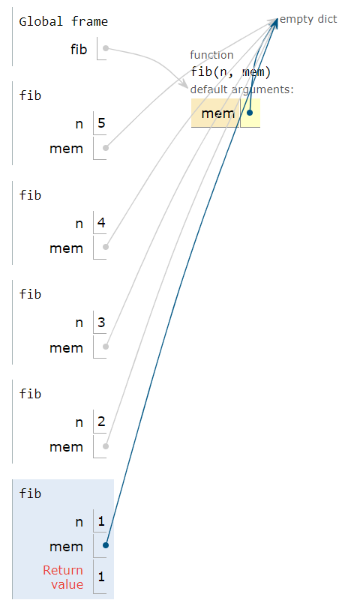

## 6. Método "Divide y vencerás" y recursividad

* Técnica de resolución de problemas:
    * Si el problema es fácil, resolverlo
    * Si es difícil, dividirlo en partes más pequeñas


### Ejemplo potencia $x^n$
* Solución directa
* Solución recursiva (divide y vencerás)
* Solución recursiva con dos casos de tamaños similares (divide y vencerás)

In [ ]:
#Solución directa
def pot_d(x, n):
    res = 1
    for i in range(n):
        res = res * x
    return res

In [ ]:
pot_d(15, 300)

67201306530145677691227706450599008677218833635331469498134353103850815627567935203598418279174424696301669832711078926054889744719967996576630443115841300927690884038379151711968495939730373490224964349010505512135479212699421321404087209170778595312054887078716487128925063696497496197915895863887572847552285583427877924123094999231398105621337890625

In [ ]:
%time pot_d(15, 30000)
#Si el resultado es un entero muy grande, la versión de Python puede devolver un error
#al convertir el entero a string para mostrarlo (con la versión 3.10.7 me da error):
#ValueError: Exceeds the limit (4300) for integer string conversion

CPU times: total: 78.1 ms
Wall time: 68.5 ms


ValueError: Exceeds the limit (4300) for integer string conversion

In [ ]:
sys.get_int_max_str_digits()   #El tamaño máximo de un int en número de dígitos es el dato por la función

4300

In [ ]:
sys.set_int_max_str_digits(40000) #Ampliación del límite
%time pot_d(15, 30000)

CPU times: total: 78.1 ms
Wall time: 79 ms


...

In [ ]:
#Solución recursiva
def pot_r(x, n):
  if n == 1:
     return x
  return x * pot_r(x, n-1)


**Ejemplos de aplicación de la función para ver su desarrollo:**

n=8 --> x * x^7 = x * x * x^6  =  x * x * x * x^5 = ... = x * x * x * x * x * x * x * x   
n=9 --> x * x^8 = x * x * x^7  =  x * x * x * x^6 = ... = x * x * x * x * x * x * x * x * x   
Cada vez que se llama a pot_r(x,n) dentro de la función se hace con un n de tamaño n-1

In [ ]:
%time pot_r(15, 30000)  #Se bloquea el kernel

**Divide y vencerás, dos casos de tamaño similar**
 * $x^{n/2} \cdot x^{n/2}$ si $n$ es par
 * $x^{(n-1)/2} \cdot x^{(n-1)/2} \cdot x$ si $n$ es impar

In [ ]:
#Solución recursiva con dos casos de tamaño similar
def pot(x, n):
    if n == 1: return x
    if n % 2 == 0:
        #print("Llamada a pot(x,n//2):",x,n//2)
        y = pot(x, n//2)
        return y*y
    #print("Llamada a pot(x,n//2):",x,n//2)
    y = pot(x, (n-1)//2)
    return y*y*x

**Ejemplos de aplicación de la función para ver su desarrollo:**

n=8 --> x^4 * x^4  = x^2 * x^2   *  x^2 * x^2  
n=9 --> x^4 * x^4 * x = x^2 * x^2   *  x^2 * x^2 * x  
Cada vez que se llama a pot(x,n) dentro de la función se hace con un n de tamaño n//2

In [ ]:
%time pot(15, 30000)

CPU times: total: 0 ns
Wall time: 3.78 ms


...

**Comparación de resultados de las 3 funciones implementadas pot_d, pot_r y pot con los argumentos:(15,30000) (en un mismo ordenador):**
    
    -Función directa iterativa - pot_d: Tiempo de ejecución 139 ms
    
    -Función recursiva - pot_r - con llamada recursiva de tamaño n-1: Tiempo ejecución: Bloqueo del kernel
    
    -Función recursiva - pot - con llamada recursiva de tamaño n//2: Tiempo ejecución: 3.78 ms
    